1. label encodig
2. 결측치 확인
3. label 갯수 확인
4. feature selection

In [37]:
# 구글 드라이브 연결 
from google.colab import drive
drive.mount('/content/drive')
folder_dir = "/content/drive/MyDrive/Colab Notebooks/"
DATA_FILE = "titanic.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

In [39]:
# 마운트 및 csv파일 출력

import pandas as pd
import os

# 디렉토리 경로와 파일명을 결합하여 파일 시스템 내 절대 경로를 확정
file_path = os.path.join(folder_dir, DATA_FILE)

# CSV 데이터 파싱 및 메모리 내 DataFrame 객체 생성
try:
    df = pd.read_csv(file_path)
    
    # Colab 인터랙티브 환경의 데이터 렌더링 기능을 활용한 출력
    display(df)
except FileNotFoundError:
    print(f"오류: 지정된 경로에서 파일을 식별할 수 없습니다. ({file_path})")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [40]:
# 테스트셋, 학습셋 형성

# X = df.drop('Name',axis = 1)

unnecessary_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin',"Survived"] # 불필요한 컬럼 제거

# 결측값 처리
df['Age'] = df['Age'].fillna(df['Age'].median())  # 나이의 중앙값으로 결측값 대체
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) # 승선 항구의 최빈값으로 결측값 대체


# 데이터 인코딩
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1}) # 성별을 숫자로 전환

le = LabelEncoder()
df['Embarked'] = le.fit_transform(df['Embarked'].astype(str)) # 레이블인코딩: 'S'는 0, 'C'는 1, 'Q'는 2와 같이 숫자로 단순 매핑

X = df.drop(unnecessary_cols,axis = 1)

display(X)

Y=df['Survived']
display(Y)

## 테스트 집단 추출



X_train, X_test, Y_train, Y_test = train_test_split(X, Y,test_size=0.25,random_state=0)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,2
1,1,1,38.0,1,0,71.2833,0
2,3,1,26.0,0,0,7.9250,2
3,1,1,35.0,1,0,53.1000,2
4,3,0,35.0,0,0,8.0500,2
...,...,...,...,...,...,...,...
886,2,0,27.0,0,0,13.0000,2
887,1,1,19.0,0,0,30.0000,2
888,3,1,28.0,1,2,23.4500,2
889,1,0,26.0,0,0,30.0000,0


,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [41]:
titanicLogisticRegression = LogisticRegression(random_state=0)
titanicLogisticRegression.fit(X_train, Y_train)

predLogisticRegression = titanicLogisticRegression.predict(X_test)

print ("\n--- Logistic Regression Classifier ---")
print (accuracy_score(Y_test, predLogisticRegression))
print (confusion_matrix(Y_test, predLogisticRegression))


--- Logistic Regression Classifier ---
0.7937219730941704
[[116  23]
 [ 23  61]]


In [42]:
titanicMLPClassifier = MLPClassifier(random_state=0)
titanicMLPClassifier.fit(X_train, Y_train)

predMLPClassifier = titanicMLPClassifier.predict(X_test)

print ("\n--- Neural Network Classifier ---")
print (accuracy_score(Y_test, predMLPClassifier))
print (confusion_matrix(Y_test, predMLPClassifier))


--- Neural Network Classifier ---
0.8116591928251121
[[121  18]
 [ 24  60]]


In [43]:
print ("\n--- Radom Forest ---")
titanicRandomForestClassifier = RandomForestClassifier(random_state=0)
titanicRandomForestClassifier.fit(X_train, Y_train)
predRandomForestClassifier = predLogisticRegression = titanicRandomForestClassifier.predict(X_test)
print(accuracy_score(Y_test,predRandomForestClassifier))
print (confusion_matrix(Y_test, predRandomForestClassifier))


--- Radom Forest ---
0.8385650224215246
[[123  16]
 [ 20  64]]


In [44]:
titanicSVC = SVC(random_state=0)
titanicSVC.fit(X_train, Y_train)

predSVC = predLogisticRegression = titanicSVC.predict(X_test)

print("\n--- SVM Classifier ---")
print(accuracy_score(Y_test, predSVC))
print(confusion_matrix(Y_test, predSVC))


--- SVM Classifier ---
0.7219730941704036
[[133   6]
 [ 56  28]]


In [45]:

# Build a decision tree classifier and predict

titanicDecisionTreeClassifier = DecisionTreeClassifier(random_state=0)
titanicDecisionTreeClassifier.fit(X_train, Y_train)

predDecisionTreeClassifier = titanicDecisionTreeClassifier.predict(X_test)

print ("\n--- Decision Tree Classifier ---")
print (accuracy_score(Y_test, predDecisionTreeClassifier))
print (confusion_matrix(Y_test, predDecisionTreeClassifier))


--- Decision Tree Classifier ---
0.7802690582959642
[[115  24]
 [ 25  59]]


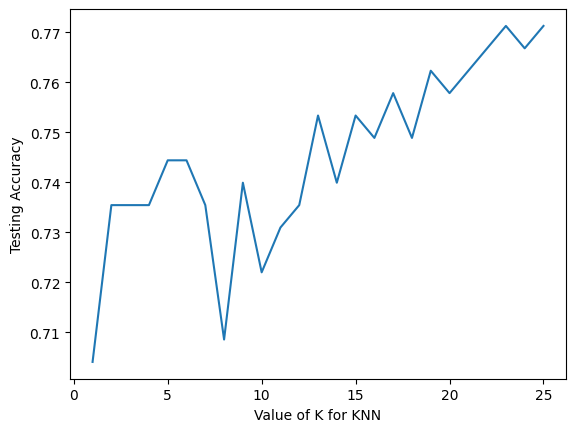

In [46]:


# 1. K의 범위 설정 (예: 1부터 25까지)
k_range = range(1, 26)
scores = []

# 2. 각 K값에 대해 모델 학습 및 검증
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, Y_train)
    Y_pred = knn.predict(X_test)
    scores.append(metrics.accuracy_score(Y_test, Y_pred))

# 3. 결과 시각화
plt.plot(k_range, scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Testing Accuracy')
plt.show()